Data Engineering module (Week 2) - Rationale: These libraries are required for Analytical and statistical analysis as well as EDA

In [10]:
import pandas as pd # Importing library to laod data
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

Data Engineering module (Week 2 and Week 3) Rationale: Loading the datasets and dropping unnecessary columns

In [11]:
borough_crime_csv_url = '/content/MPS_Borough_Level_Crime_Analysis_Ready.csv'
borough_pre_crime_df = pd.read_csv(borough_crime_csv_url) # Loading the dataset
borough_crime_df = borough_pre_crime_df.drop(columns=['MajorText'], errors='ignore') # Drops MajorText from column without giving an error in case it isn't there
borough_crime_df.head()

,Crime_Type,Borough,202401,202402,202403,202404,202405,202406,202407,202408,...,202503,202504,202505,202506,202507,202508,202509,202510,202511,202512
0,ARSON,Barking and Dagenham,4,5,6,3,8,2,3,10,...,4,12,10,10,11,10,5,6,8,7
1,CRIMINAL DAMAGE,Barking and Dagenham,126,124,134,112,102,106,131,114,...,103,124,108,124,137,126,100,100,106,126
2,BURGLARY BUSINESS AND COMMUNITY,Barking and Dagenham,31,21,30,24,28,33,21,26,...,24,20,27,25,24,23,23,16,22,23
3,RES BURGLARY OF A HOME,Barking and Dagenham,57,33,45,42,31,31,28,34,...,58,30,31,35,32,29,31,33,64,52
4,RES BURGLARY OF UNCONNECTED BUILDING,Barking and Dagenham,10,16,5,10,11,6,8,12,...,20,11,7,16,5,13,12,22,15,23


In [12]:
ward_crime_csv_url = '/content/MPS Ward Level Crime (most recent 24 months)(modified).csv'
ward_pre_crime_df = pd.read_csv(ward_crime_csv_url) # Loading the dataset
ward_crime_df = ward_pre_crime_df.drop(columns=['MajorText', 'WardCode'], errors='ignore') # Drops MajorText from column without giving an error in case it isn't there
ward_crime_df.head()

,Crime_Type,Ward,Borough,202401,202402,202403,202404,202405,202406,202407,...,202503,202504,202505,202506,202507,202508,202509,202510,202511,202512
0,ARSON,Heathrow Villages,Aviation Security (SO18),3,0,2,0,0,1,2,...,1,0,0,5,3,2,0,0,1,3
1,CRIMINAL DAMAGE,Heathrow Villages,Aviation Security (SO18),25,28,21,31,24,22,30,...,27,25,15,18,25,24,30,26,25,40
2,BURGLARY BUSINESS AND COMMUNITY,Heathrow Villages,Aviation Security (SO18),2,9,6,3,3,0,6,...,2,5,6,4,1,4,2,5,2,3
3,RES BURGLARY OF A HOME,Heathrow Villages,Aviation Security (SO18),11,7,3,1,2,5,3,...,10,2,1,8,1,4,2,3,2,5
4,RES BURGLARY OF UNCONNECTED BUILDING,Heathrow Villages,Aviation Security (SO18),1,0,1,1,0,0,1,...,0,1,0,1,0,2,1,0,1,1


Data Engineering (Week 3) - Rationale: Check if datasets needs to be reshaped to make analysis more effective. In this case, reshaping is required

In [13]:
borough_crime_df.info() # Checking column names for boroughs

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 26 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Crime_Type  1025 non-null   object
 1   Borough     1025 non-null   object
 2   202401      1025 non-null   int64 
 3   202402      1025 non-null   int64 
 4   202403      1025 non-null   int64 
 5   202404      1025 non-null   int64 
 6   202405      1025 non-null   int64 
 7   202406      1025 non-null   int64 
 8   202407      1025 non-null   int64 
 9   202408      1025 non-null   int64 
 10  202409      1025 non-null   int64 
 11  202410      1025 non-null   int64 
 12  202411      1025 non-null   int64 
 13  202412      1025 non-null   int64 
 14  202501      1025 non-null   int64 
 15  202502      1025 non-null   int64 
 16  202503      1025 non-null   int64 
 17  202504      1025 non-null   int64 
 18  202505      1025 non-null   int64 
 19  202506      1025 non-null   int64 
 20  202507  

In [14]:
ward_crime_df.info() # Checking column names for wards

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18707 entries, 0 to 18706
Data columns (total 27 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Crime_Type  18707 non-null  object
 1   Ward        18707 non-null  object
 2   Borough     18707 non-null  object
 3   202401      18707 non-null  int64 
 4   202402      18707 non-null  int64 
 5   202403      18707 non-null  int64 
 6   202404      18707 non-null  int64 
 7   202405      18707 non-null  int64 
 8   202406      18707 non-null  int64 
 9   202407      18707 non-null  int64 
 10  202408      18707 non-null  int64 
 11  202409      18707 non-null  int64 
 12  202410      18707 non-null  int64 
 13  202411      18707 non-null  int64 
 14  202412      18707 non-null  int64 
 15  202501      18707 non-null  int64 
 16  202502      18707 non-null  int64 
 17  202503      18707 non-null  int64 
 18  202504      18707 non-null  int64 
 19  202505      18707 non-null  int64 
 20  202506

Data Visualisation and Communication (Coursework) and corrected using ChatGPT AI - Rationale: Crime dataset needs to be reshaped into the long format for analysis to be carried out as data cannot be used in analysis if date format is on the X axis.

In [15]:
borough_crime_df_long = borough_crime_df.melt(
    id_vars=['Borough', 'Crime_Type'], # Columns to keep the same
    var_name='Month_Year', # Name for the variable column - Turns the month columns into 1 column called "Month_Year"
    value_name='Crime_Count' # Names for the values - Puts crime count into a new column named "Crime_Count"
)

In [17]:
borough_crime_df_long.head()

,Borough,Crime_Type,Month_Year,Crime_Count
0,Barking and Dagenham,ARSON,202401,4
1,Barking and Dagenham,CRIMINAL DAMAGE,202401,126
2,Barking and Dagenham,BURGLARY BUSINESS AND COMMUNITY,202401,31
3,Barking and Dagenham,RES BURGLARY OF A HOME,202401,57
4,Barking and Dagenham,RES BURGLARY OF UNCONNECTED BUILDING,202401,10


In [16]:
ward_crime_df_long = ward_crime_df.melt(
    id_vars=['Borough', 'Ward', 'Crime_Type'], # Columns to keep the same
    var_name='Month_Year', # Name for the variable column - Turns the month columns into 1 column called "Month_Year"
    value_name='Crime_Count' # Names for the values - Puts crime count into a new column named "Crime_Count"
)

In [18]:
ward_crime_df_long.head()

,Borough,Ward,Crime_Type,Month_Year,Crime_Count
0,Aviation Security (SO18),Heathrow Villages,ARSON,202401,3
1,Aviation Security (SO18),Heathrow Villages,CRIMINAL DAMAGE,202401,25
2,Aviation Security (SO18),Heathrow Villages,BURGLARY BUSINESS AND COMMUNITY,202401,2
3,Aviation Security (SO18),Heathrow Villages,RES BURGLARY OF A HOME,202401,11
4,Aviation Security (SO18),Heathrow Villages,RES BURGLARY OF UNCONNECTED BUILDING,202401,1


Splitting Month and year so time-series plots are possible and merging (integration) with other datasets is possible

In [19]:
borough_crime_df_long['Year'] = borough_crime_df_long['Month_Year'].astype(str).str[:4] # Creating a new column "Year"
borough_crime_df_long['Month'] = borough_crime_df_long['Month_Year'].astype(str).str[4:] # Creating a new column called "Month"
borough_crime_df_long = borough_crime_df_long.drop(columns=['Month_Year']) # Dropping "Month_Year" after separating them
borough_crime_df_long.head() # For boroughs

,Borough,Crime_Type,Crime_Count,Year,Month
0,Barking and Dagenham,ARSON,4,2024,01
1,Barking and Dagenham,CRIMINAL DAMAGE,126,2024,01
2,Barking and Dagenham,BURGLARY BUSINESS AND COMMUNITY,31,2024,01
3,Barking and Dagenham,RES BURGLARY OF A HOME,57,2024,01
4,Barking and Dagenham,RES BURGLARY OF UNCONNECTED BUILDING,10,2024,01


In [20]:
ward_crime_df_long['Year'] = ward_crime_df_long['Month_Year'].astype(str).str[:4] # Creating a new column "Year"
ward_crime_df_long['Month'] = ward_crime_df_long['Month_Year'].astype(str).str[4:] # Creating a new column called "Month"
ward_crime_df_long = ward_crime_df_long.drop(columns=['Month_Year']) # Dropping "Month_Year" after separating them
ward_crime_df_long.head() # For Months

,Borough,Ward,Crime_Type,Crime_Count,Year,Month
0,Aviation Security (SO18),Heathrow Villages,ARSON,3,2024,01
1,Aviation Security (SO18),Heathrow Villages,CRIMINAL DAMAGE,25,2024,01
2,Aviation Security (SO18),Heathrow Villages,BURGLARY BUSINESS AND COMMUNITY,2,2024,01
3,Aviation Security (SO18),Heathrow Villages,RES BURGLARY OF A HOME,11,2024,01
4,Aviation Security (SO18),Heathrow Villages,RES BURGLARY OF UNCONNECTED BUILDING,1,2024,01


Machine learning and Data Mining (Coursework) - Rationale: Missing value imputation so that there are no empty cells and analysis can be carried out without errors

In [21]:
borough_crime_df_long['Crime_Count'] = borough_crime_df_long['Crime_Count'].fillna(0) # Any months missing data becomes 0
borough_crime_df_long.head(15)

,Borough,Crime_Type,Crime_Count,Year,Month
0,Barking and Dagenham,ARSON,4,2024,01
1,Barking and Dagenham,CRIMINAL DAMAGE,126,2024,01
2,Barking and Dagenham,BURGLARY BUSINESS AND COMMUNITY,31,2024,01
3,Barking and Dagenham,RES BURGLARY OF A HOME,57,2024,01
4,Barking and Dagenham,RES BURGLARY OF UNCONNECTED BUILDING,10,2024,01
5,Barking and Dagenham,POSSESSION OF DRUGS,71,2024,01
6,Barking and Dagenham,TRAFFICKING OF DRUGS,29,2024,01
7,Barking and Dagenham,FRAUD AND FORGERY,0,2024,01
8,Barking and Dagenham,MISC CRIMES AGAINST SOCIETY,27,2024,01
9,Barking and Dagenham,POSSESSION OF WEAPONS,10,2024,01


In [22]:
ward_crime_df_long['Crime_Count'] = ward_crime_df_long['Crime_Count'].fillna(0) # Any months missing data becomes 0
ward_crime_df_long.head(15)

,Borough,Ward,Crime_Type,Crime_Count,Year,Month
0,Aviation Security (SO18),Heathrow Villages,ARSON,3,2024,01
1,Aviation Security (SO18),Heathrow Villages,CRIMINAL DAMAGE,25,2024,01
2,Aviation Security (SO18),Heathrow Villages,BURGLARY BUSINESS AND COMMUNITY,2,2024,01
3,Aviation Security (SO18),Heathrow Villages,RES BURGLARY OF A HOME,11,2024,01
4,Aviation Security (SO18),Heathrow Villages,RES BURGLARY OF UNCONNECTED BUILDING,1,2024,01
5,Aviation Security (SO18),Heathrow Villages,POSSESSION OF DRUGS,5,2024,01
6,Aviation Security (SO18),Heathrow Villages,TRAFFICKING OF DRUGS,3,2024,01
7,Aviation Security (SO18),Heathrow Villages,FRAUD AND FORGERY,0,2024,01
8,Aviation Security (SO18),Heathrow Villages,MISC CRIMES AGAINST SOCIETY,97,2024,01
9,Aviation Security (SO18),Heathrow Villages,POSSESSION OF WEAPONS,3,2024,01


Data Engineering (week 2) - Rationale: Saving dataset or datasets so that they can all go through EDA in a separate notebook independent of the pre-processing

In [23]:
borough_crime_df_long.to_csv("Borough_Crime_Data_Jan2024_Dec2025.csv", index=False)

In [24]:
ward_crime_df_long.to_csv("Ward_Crime_Data_Jan2024_Dec2025.csv", index=False)

Data Engineering (Week 2) Rationale: Loading the dataset to do initial analysis

In [25]:
borough_processed_crime = '/content/Borough_Crime_Data_Jan2024_Dec2025.csv'
borough_processed_crime = pd.read_csv(borough_processed_crime)
borough_processed_crime.head()

,Borough,Crime_Type,Crime_Count,Year,Month
0,Barking and Dagenham,ARSON,4,2024,1
1,Barking and Dagenham,CRIMINAL DAMAGE,126,2024,1
2,Barking and Dagenham,BURGLARY BUSINESS AND COMMUNITY,31,2024,1
3,Barking and Dagenham,RES BURGLARY OF A HOME,57,2024,1
4,Barking and Dagenham,RES BURGLARY OF UNCONNECTED BUILDING,10,2024,1


In [26]:
ward_processed_crime = '/content/Ward_Crime_Data_Jan2024_Dec2025.csv'
ward_processed_crime = pd.read_csv(ward_processed_crime)
ward_processed_crime.head()

,Borough,Ward,Crime_Type,Crime_Count,Year,Month
0,Aviation Security (SO18),Heathrow Villages,ARSON,3,2024,1
1,Aviation Security (SO18),Heathrow Villages,CRIMINAL DAMAGE,25,2024,1
2,Aviation Security (SO18),Heathrow Villages,BURGLARY BUSINESS AND COMMUNITY,2,2024,1
3,Aviation Security (SO18),Heathrow Villages,RES BURGLARY OF A HOME,11,2024,1
4,Aviation Security (SO18),Heathrow Villages,RES BURGLARY OF UNCONNECTED BUILDING,1,2024,1


Data Engineering (Week 3) and modified with the help of AI assistant - Rationale: Barplots aggregate data and will not squeeze the labels together unlike the barchart. Good to see aggregated data

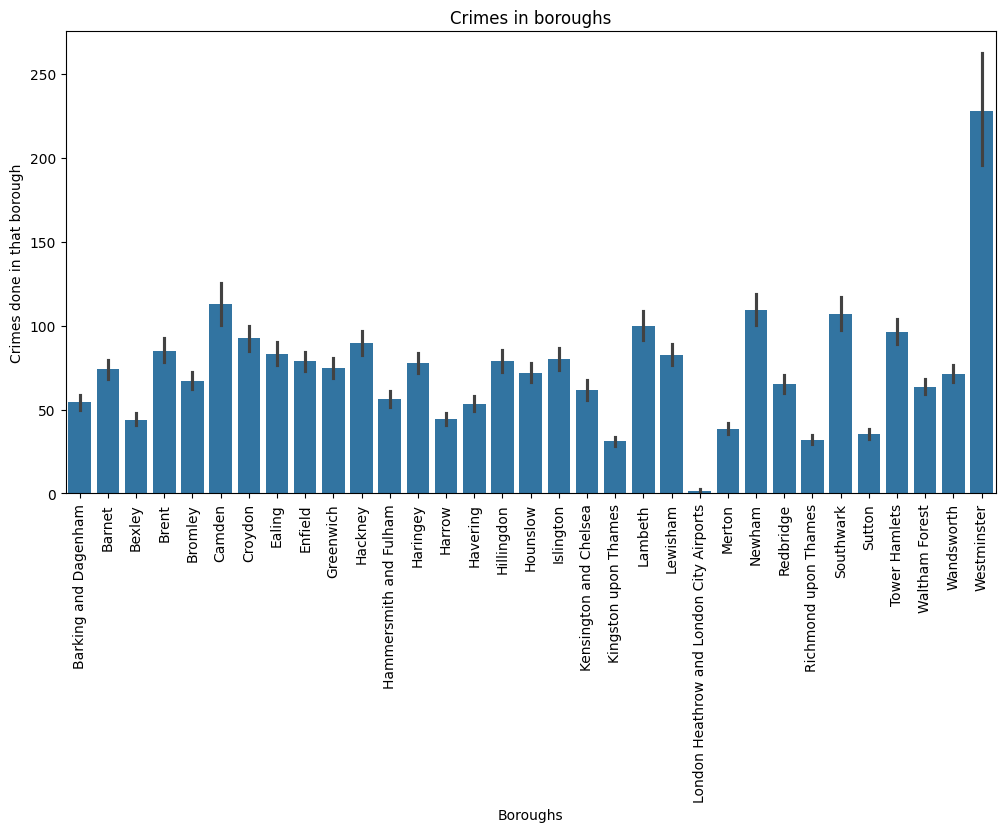

In [27]:
plt.figure(figsize= (12, 6))
sns.barplot(x=borough_processed_crime['Borough'].values, y=borough_processed_crime['Crime_Count'].values) # Setting the axes
plt.xticks(rotation=90)
plt.xlabel('Boroughs')
plt.ylabel('Crimes done in that borough')
plt.title('Crimes in boroughs')
plt.show()
# Aggregates the values together despite boroughs repeating multiple times in dataset

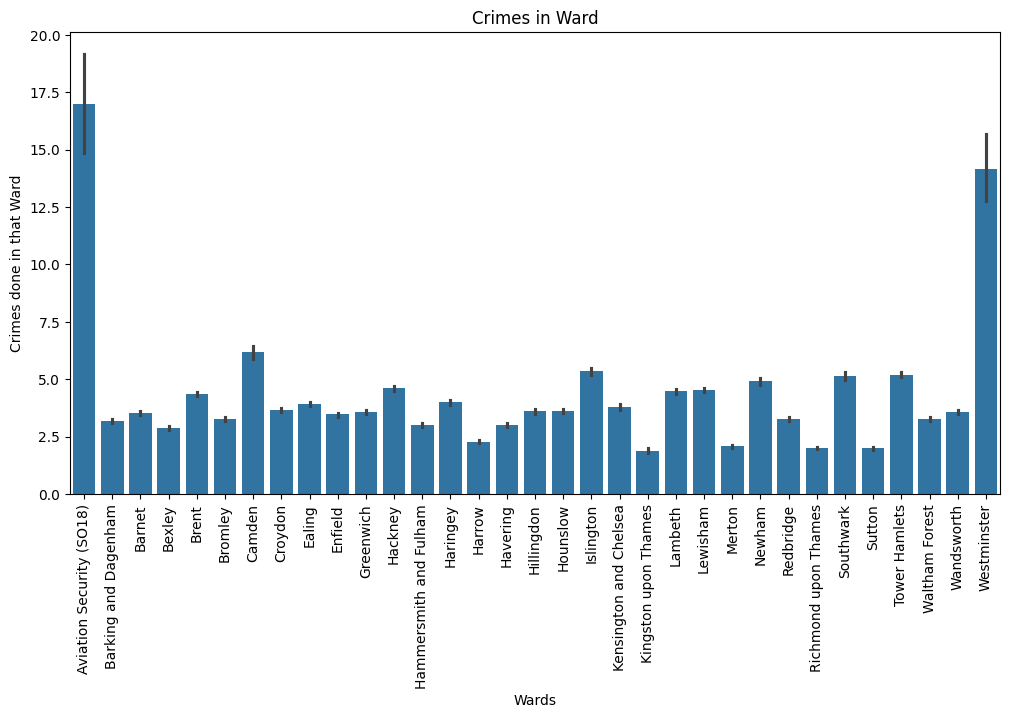

In [28]:
plt.figure(figsize= (12, 6))
sns.barplot(x=ward_processed_crime['Borough'].values, y=ward_processed_crime['Crime_Count'].values) # Setting the axes
plt.xticks(rotation=90)
plt.xlabel('Wards')
plt.ylabel('Crimes done in that Ward')
plt.title('Crimes in Ward')
plt.show()
# Aggregates the values together despite wards repeating multiple times in dataset